# Интеллектуальный анализ данных – весна 2026
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [1]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [ ]:
#df = pd.read_csv('content\\tweets_coronavirus.csv', encoding='latin-1')
df = pd.read_csv('/content/tweets_coronavirus.csv', encoding='latin-1')
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
13943,20729,65681,NaN,23-03-2020,A Sikh non profit has launched an emergency fo...,Positive
30872,41776,86728,Amsterdam,11-04-2020,Snapshot of incidents across the Paramedics ...,Negative
21374,29874,74826,"Tanzania, Kenya and Uganda",01-04-2020,I urge to resist panic buying We will be close...,Negative
5402,10361,55313,"San Jose, Costa Rica",19-03-2020,Tomorrow #Bogota will be on complete curfew fo...,Extremely Positive


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [3]:
df['Sentiment'] = np.where(df['Sentiment'].isin(['Extremely Positive', 'Positive']), 1, 0)
df

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,1
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,1
2,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,1
3,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",0
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,1
...,...,...,...,...,...,...
33439,44949,89901,OHIO,14-04-2020,I never that weÃÂd be in a situation &amp; w...,1
33440,44950,89902,NaN,14-04-2020,@MrSilverScott you are definitely my man. I fe...,1
33441,44952,89904,NaN,14-04-2020,Response to complaint not provided citing COVI...,0
33442,44953,89905,NaN,14-04-2020,You know itÃÂs getting tough when @KameronWi...,1


Сбалансированы ли классы?

In [4]:
vc = df['Sentiment'].value_counts(normalize=True)
print(vc)

Sentiment
1    0.539589
0    0.460411
Name: proportion, dtype: float64


**Ответ:** сбалансированны

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [5]:
print("Число пропусков:")
print(df.isna().sum())

df['Location'] = df['Location'].fillna('Unknown')

print(f"Теперь число пропусков: {df.isna().sum().sum()}")

Число пропусков:
UserName            0
ScreenName          0
Location         7049
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64
Теперь число пропусков: 0


Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [6]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, random_state=0)

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [8]:
tokens = {}
for tweet in train["OriginalTweet"]:
    curr_tokens = tweet.lower().split()
    for tok in curr_tokens:
        if tok in tokens:
            tokens[tok] += 1
        else:
            tokens[tok] = 1


Какой размер словаря получился?

In [8]:
print(f"Размер словаря: {len(tokens)}")

Размер словаря: 79755


Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [9]:
top_tokens = sorted(tokens.items(), key=lambda x: x[1], reverse=True)[:10]
for cur_pair in top_tokens:
    print(f"{cur_pair[0]}: {cur_pair[1]}")

the: 26815
to: 23373
and: 14684
of: 13012
a: 11737
in: 11198
for: 8566
#coronavirus: 8223
is: 7383
are: 7050


**Ответ:** Самыми популярными оказались предлоги (of, in, to, for), артикли (the, a), союзы (and), глаголы-связки (is, are). Эти токены не несут практически никакой информации и не влияют на тональность текста. Также популярным является хэштег #coronavirus, так как коронавирус - основная тема данных твитов.

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [9]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_set = set(stopwords.words('english'))
filtered_tokens = {tok: count for tok, count in tokens.items() if tok not in stop_set}

top_tokens_new = sorted(filtered_tokens.items(), key=lambda x: x[1], reverse=True)[:10]
for cur_pair in top_tokens_new:
    print(f"{cur_pair[0]}: {cur_pair[1]}")

#coronavirus: 8223
prices: 3891
food: 3820
grocery: 3469
supermarket: 3288
people: 3175
covid-19: 3173
store: 3155
#covid19: 2471
&amp;: 2314


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\YOGA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Ответ:** В популярных токенах оказались
1. covid-19 и хэштеги #coronavirus, #covid19, отражающие основную тему твитов
2. Слова, связанные с темой экономики/потребления (prices, food, grocery, supermarket, people, store)- слова, связанные со сферой, на которую больше всего повлияла пандемия
3. &amp; - амперсанд, то же самое, что и and

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [11]:
last_tokens_new = sorted(filtered_tokens.items(), key=lambda x: x[1])[:20]
for cur_pair in last_tokens_new:
    print(f"{cur_pair[0]}: {cur_pair[1]}")

https://t.co/1m881cwfuv: 1
happy..: 1
https://t.co/z0intks34x: 1
mnuchinãâs: 1
brink.: 1
https://t.co/jmobv8z0u0: 1
university's: 1
teaching.): 1
@catholicpres: 1
@catholicuniv: 1
https://t.co/evqby035wf: 1
https://t.co/riqrhxxeim: 1
@@ballardspahrll: 1
#aca: 1
easier...take: 1
ãânecessaryãâ: 1
https://t.co/0fmsmlgepm: 1
husted:: 1
irishman: 1
#happystpatricksday!: 1


**Ответ:** среди непопулярных токенов оказались
1. Ссылки и отметки других пользователей, т.к. скорее всего они единоразово использовались для указания другого пользователя или твита. Их лучше удалить
2. Специфические хэштеги. Можно оставить
3. Опечатки и "склеившиеся" слова из-за знаков препинания, т.к. такие ошибки происходят нечасто. Можно исправить при токенизации.


Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [10]:
from nltk.tokenize import TweetTokenizer

tknzr = TweetTokenizer()
tokens = {}

for tweet in train['OriginalTweet']:
    curr_tokens = tknzr.tokenize(tweet.lower())
    for tok in curr_tokens:
        if tok in tokens:
            tokens[tok] += 1
        else:
            tokens[tok] = 1

top_tokens = sorted(tokens.items(), key=lambda x: x[1], reverse=True)[:10]
for cur_pair in top_tokens:
    print(f"{cur_pair[0]}: {cur_pair[1]}")

the: 26993
.: 24118
to: 23478
,: 17571
and: 14825
of: 13044
a: 11891
in: 11348
?: 9524
#coronavirus: 8808


**Ответ:** этот топ токенов отличается от предыдущего наличием знаков препинания. До этого они не отделялись от слов пробелами, поэтому не попали в топ, но сейчас их выделил токенайзер

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [11]:
from string import punctuation

stop_and_punct = stop_set.union(set(punctuation))

filtered_tokens = {}
for tok, count in tokens.items():
    if tok not in stop_and_punct:
        filtered_tokens[tok] = count

top_tokens_filtered = sorted(filtered_tokens.items(), key=lambda x: x[1], reverse=True)[:10]
for cur_pair in top_tokens_filtered:
    print(f"{cur_pair[0]}: {cur_pair[1]}")

#coronavirus: 8808
â: 7415
: 7311
19: 7167
covid: 6253
prices: 4601
: 4372
food: 4367
store: 3877
supermarket: 3805


**Ответ:** часть слов осталась такой же, как и в предыдущем топе без стоп-слов: связанные с ковидом #coronavirus, covid и связанные с магазинами prices, food, store, supermarket. covid-19 токенайзер разделил на 2 отдельных токена, что ухудшило интерпритацию. Остальне токены - одиночные буквы не латинского алфавита или символы, которые не отобразились в кодировке

Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [14]:
filtered_tokens_new = filtered_tokens.copy()
for tok, count in filtered_tokens.items():
    if len(tok) == 1 and ord(tok) >= 128:
        filtered_tokens_new.pop(tok)

sorted_tokens = sorted(filtered_tokens_new.items(), key=lambda x: x[1], reverse=True)

top_tokens_filtered = sorted_tokens[:10]
print("Топ 10 популярных токенов")
for cur_pair in top_tokens_filtered:
    print(f"{cur_pair[0]}: {cur_pair[1]}")

last_tokens_filtered = sorted_tokens[-20:]
print()
print("Топ 20 непопулярных токенов")
for cur_pair in last_tokens_filtered:
    print(f"{cur_pair[0]}: {cur_pair[1]}")

Топ 10 популярных токенов
#coronavirus: 8808
19: 7167
covid: 6253
prices: 4601
food: 4367
store: 3877
supermarket: 3805
grocery: 3523
people: 3463
#covid19: 2589

Топ 20 непопулярных токенов
https://t.co/lw1r0rm7xs: 1
https://t.co/5cbliqzx7l: 1
now.when: 1
milion: 1
skellig: 1
@skelligsix18: 1
#skelligcoast2kms: 1
#southkerry: 1
https://t.co/zjcl195vqs: 1
@srinivasiyc: 1
https://t.co/iaek4fwsgz: 1
premiership: 1
non-playing: 1
subsidise: 1
playersã: 1
renewing: 1
flew: 1
@torontopearson: 1
@680news: 1
https://t.co/7j2y3rsld9: 1


**Ответ:**

Осталось также: большая часть токенов в топ 10 популярных осталась такой же, в топ 20 непопулярных остались отметки пользователей, ссылки и редкие слова

Улучшилось: в топе непопулярных стало меньше "склеившихся" со знаками препинания токенов

Ухудшилось: covid-19 разделился на 2 токена -> ухудшилась интерпритация, лучше было оставить covid-19 единым токеном

Можно сказать, что новая токенизация вышла лучше, чем по пробелам

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [15]:
hashtags = {}
for tok, count in filtered_tokens_new.items():
    if tok[0] == "#":
        hashtags[tok] = count

top_hashtags = sorted(hashtags.items(), key=lambda x: x[1], reverse=True)[:10]

for cur_pair in top_hashtags:
    print(f"{cur_pair[0]}: {cur_pair[1]}")

#coronavirus: 8808
#covid19: 2589
#covid_19: 1734
#covid2019: 946
#toiletpaper: 744
#covid: 641
#socialdistancing: 465
#coronacrisis: 448
#pandemic: 257
#coronaviruspandemic: 249


**Ответ:** Все популярные хэштеги оказалсь или различными написаниями названия вируса, или как-то с ним связаны (#pandemic, #socialdistancing, #toiletpaper) 

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [16]:
links = {}
for tok, count in filtered_tokens_new.items():
    if tok.find("https://t.co") == 0:
        links[tok] = count

top_links = sorted(links.items(), key=lambda x: x[1], reverse=True)[:10]

for cur_pair in top_links:
    print(f"{cur_pair[0]}: {cur_pair[1]}")

https://t.co/oxa7swtond: 5
https://t.co/gp3eusapl8: 4
https://t.co/deftrui1pfãâ: 3
https://t.co/wrlhyzizaa: 3
https://t.co/kuwipf1kqw: 3
https://t.co/zjnrx6dkkn: 3
https://t.co/3gbbdpdjat: 3
https://t.co/e2znxajpre: 3
https://t.co/catkegayoy: 3
https://t.co/g63rp042ho: 3


**Ответ:** число упоминаний самой популярной ссылки намного меньше, чем для самого популярного хэштега (5 и 8808 соответственно). Информация о ссылке на конкретную страницу не очень полезна, т.к. мы не можем посмотреть, на что конкретно ссылаемся

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [ ]:
def custom_tokenizer(text):
  tknzr = TweetTokenizer()
  first_tokens = tknzr.tokenize(text.lower())

  stop_set = set(stopwords.words('english'))
  stop_and_punct = stop_set.union(set(punctuation))
  
  tokens = []
  for tok in first_tokens:
    if (tok not in stop_and_punct) and ("https://t.co" not in tok) and not (len(tok) == 1 and ord(tok) >= 128):
        tokens.append(tok)
  return tokens


In [18]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(tokenizer=custom_tokenizer, token_pattern=None).fit(train["OriginalTweet"])

print(len(cv.vocabulary_))

45288


**Ответ:** Размер словаря примерно вдвое меньше изначального

Посмотрим на какой-нибудь конкретный твитт:

In [20]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

('Nice one @SkyNews lets not panic but show ppl in france queueing for food!!! #CoronavirusOutbreak #COVID2019 brainless!! Ffs',
 np.int64(0))

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [21]:
tweet9023 = train.iloc[ind]['OriginalTweet']

x = cv.transform([tweet9023])
vec = x.toarray()[0]
feature_names = cv.get_feature_names_out()

max_all = vec.max()
min_nonzero = vec[vec > 0].min()
max_inds = np.where(vec == max_all)[0]
min_inds = np.where(vec == min_nonzero)[0]

is_max = False
print("Самые важные токены")
for i in max_inds:
    print(f"{feature_names[i]} : {vec[i]}")
    is_max = True
if (not is_max):
    print("Таких токенов нет(")

is_min = False
print()
print("Самые неважные токены")
for i in min_inds:
    if i not in max_inds:
        print(f"{feature_names[i]} : {vec[i]}")
        is_min = True
if (not is_min):
    print("Таких токенов нет(")


Самые важные токены
#coronavirusoutbreak : 1
#covid2019 : 1
@skynews : 1
brainless : 1
ffs : 1
food : 1
france : 1
lets : 1
nice : 1
one : 1
panic : 1
ppl : 1
queueing : 1
show : 1

Самые неважные токены
Таких токенов нет(


**Ответ:** Токены определились плохо. Так получилось, потому что текст короткий и каждый токен в нём встретился по одному разу, а для определения "важности" у нас используется только частота

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(tokenizer=custom_tokenizer, token_pattern=None).fit(train["OriginalTweet"])

x_tfidf = tfidf.transform([tweet9023])
vec_tfidf = x_tfidf.toarray()[0]
feature_names_tfidf = tfidf.get_feature_names_out()

max_all = vec_tfidf.max()
min_nonzero = vec_tfidf[vec_tfidf > 0].min()
max_inds = np.where(vec_tfidf == max_all)[0]
min_inds = np.where(vec_tfidf == min_nonzero)[0]

is_max = False
print("Самые важные токены")
for i in max_inds:
    print(f"{feature_names_tfidf[i]} : {vec_tfidf[i]}")
    is_max = True
if (not is_max):
    print("Таких токенов нет(")

is_min = False
print()
print("Самые неважные токены")
for i in min_inds:
    if i not in max_inds:
        print(f"{feature_names_tfidf[i]} : {vec_tfidf[i]}")
        is_min = True
if (not is_min):
    print("Таких токенов нет(")


Самые важные токены
brainless : 0.3867641170466375

Самые неважные токены
food : 0.11328893069250721


**Ответ:** Токены определились хорошо, потому что важность стала зависеть не от частоты повторения токена в твите, а от частоты + уникальности токена в обучающих данных.
Самым важным токеном стал brainless - указывает на резко негативную эмоциональную окраску твита. Самым неважным токеном стал food - указывает на общую тему твита, но при этом (скорее всего) довольно часто встречается в остальных твитах
 

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [23]:
positive_ones = train[train['OriginalTweet'].apply(lambda x: 'amazing' in x) & (train['Sentiment'] == 1)]
positive_ones.head(15) #выберем твит 23318

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
4583,9362,54314,"Moulton, England",19-03-2020,Hearing so many stories of NHS heroes Teachers...,1
8221,13787,58739,Unknown,20-03-2020,Let s just take a minute to say THANK YOU also...,1
3183,7654,52606,"London, England",18-03-2020,"Back at the ""Frontline""\r\r\nA massive shout o...",1
24347,33577,78529,Unknown,05-04-2020,Massive thanks to @waitrose for my delivery of...,1
3281,7772,52724,"Nairobi, Kenya",18-03-2020,Crisp clean fresh air perfect ambience Covid 1...,1
8851,14552,59504,Unknown,20-03-2020,With everything going on with 19 shopping onli...,1
21299,29778,74730,"Morrisville, NC",01-04-2020,We've got newly updated info about online shop...,1
11808,18128,63080,"Brighton, England",21-03-2020,#CoronaCrisis #cornavirusuk #HelpEachOther can...,1
11674,17953,62905,Essex,21-03-2020,Thank you so much @waitrose you have been amaz...,1
10468,16499,61451,Unknown,21-03-2020,This Covid-19 is really an amazing ÃÂselecti...,1


In [24]:
tweet23318 = positive_ones.loc[23318]['OriginalTweet']
tweet23318

"Healthcare workers are amazing during this #COVID2019 pandemic but please let's not forget how amazing our Supermarket workers, chemists workers, Binmen, delivery drivers and distribution works playing a major part in keeping life going. But Healthcare is gettin all the praise"

In [25]:
x_tfidf = tfidf.transform([tweet23318])
vec_tfidf = x_tfidf.toarray()[0]
feature_names_tfidf = tfidf.get_feature_names_out()

tweet23318_df = pd.DataFrame({
    'Token': feature_names,
    'TF-IDF': vec_tfidf
})

tweet23318_df[tweet23318_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)


,Token,TF-IDF
18542,amazing,0.364550
44901,workers,0.331134
28743,healthcare,0.320907
27753,gettin,0.295395
20097,binmen,0.275646
21729,chemists,0.242064
36424,praise,0.232792
36042,playing,0.199951
24642,distribution,0.190651
31563,let's,0.185098


**Ответ:** Самыми важными токенами оказались amazing - прямо указывает на положительную окраску твита. Следующие токены уже указывают на тему твита (workers, healthcare)

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [15]:
y_train = train['Sentiment']
X_train = train.drop(columns='Sentiment')
X_train_texts = train['OriginalTweet']

In [17]:
y_test = test['Sentiment']
X_test = test.drop(columns='Sentiment')
X_test_texts = test['OriginalTweet']

In [18]:

cv = CountVectorizer(tokenizer=custom_tokenizer, token_pattern=None)
X_train_cv = cv.fit_transform(X_train_texts)
X_test_cv = cv.transform(X_test_texts)

In [22]:

tfidf = TfidfVectorizer(tokenizer=custom_tokenizer, token_pattern=None)
X_train_tfidf = tfidf.fit_transform(X_train_texts)
X_test_tfidf = tfidf.transform(X_test_texts)

Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_cv = LogisticRegression(max_iter=200)
lr_cv.fit(X_train_cv, y_train)
y_pred_train_cv = lr_cv.predict(X_train_cv)
y_pred_test_cv = lr_cv.predict(X_test_cv)

lr_tfidf = LogisticRegression(max_iter=200)
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_train_tfidf = lr_tfidf.predict(X_train_tfidf)
y_pred_test_tfidf = lr_tfidf.predict(X_test_tfidf)

print('CountVectorizer:')
print(f'Accuracy на train: {accuracy_score(y_train, y_pred_train_cv)}')
print(f'Accuracy на test: {accuracy_score(y_test, y_pred_test_cv)}')

print()
print('TfidfVectorizer:')
print(f'Accuracy на train: {accuracy_score(y_train, y_pred_train_tfidf)}')
print(f'Accuracy на test: {accuracy_score(y_test, y_pred_test_tfidf)}')

CountVectorizer:
Accuracy на train: 0.9720632208457924
Accuracy на test: 0.8671516842734702

TfidfVectorizer:
Accuracy на train: 0.9161469457496796
Accuracy на test: 0.8562886186964321


**Ответ:** Оба векторайзера показали себя хорошо, но CountVectorizer немного лучше. При этом обе модели имеют признаки переобучения (особенно у CountVectorizer большая разница между train и test accuracy).

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [26]:
from nltk.stem import SnowballStemmer

def custom_stem_tokenizer(text):
  tknzr = TweetTokenizer()
  first_tokens = tknzr.tokenize(text.lower())

  stop_set = set(stopwords.words('english'))
  stop_and_punct = stop_set.union(set(punctuation))
  
  tokens = []
  for tok in first_tokens:
    if (tok not in stop_and_punct) and ("https://t.co" not in tok) and not (len(tok) == 1 and ord(tok) >= 128):
        tokens.append(tok)

  stemmer = SnowballStemmer('english')
  tokens = [stemmer.stem(token) for token in tokens]
  return tokens

In [27]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [28]:
cv = CountVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None)
cv.fit(train['OriginalTweet'])
print(f'CountVectorizer: {len(cv.vocabulary_)}')

CountVectorizer: 36632


In [29]:
tfidf = TfidfVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None)
tfidf.fit(train['OriginalTweet'])
print(f'TfidfVectorizer: {len(tfidf.vocabulary_)}')

TfidfVectorizer: 36632


**Ответ** размер словаря уменьшился чуть больше чем на 1000 (в сравнении с обычным custom_tokenizer) и более чем вдвое по сравнению самым первым словарём - стемминг "склеил" слова с одинаковыми основаниями

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [68]:
X_train_cv = cv.fit_transform(X_train_texts)
X_test_cv = cv.transform(X_test_texts)

X_train_tfidf = tfidf.fit_transform(X_train_texts)
X_test_tfidf = tfidf.transform(X_test_texts)

lr_cv = LogisticRegression(max_iter=200)
lr_cv.fit(X_train_cv, y_train)
y_pred_train_cv = lr_cv.predict(X_train_cv)
y_pred_test_cv = lr_cv.predict(X_test_cv)

lr_tfidf = LogisticRegression(max_iter=200)
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_train_tfidf = lr_tfidf.predict(X_train_tfidf)
y_pred_test_tfidf = lr_tfidf.predict(X_test_tfidf)

print('CountVectorizer:')
print(f'Accuracy на train: {accuracy_score(y_train, y_pred_train_cv)}')
print(f'Accuracy на test: {accuracy_score(y_test, y_pred_test_cv)}')

print()
print('TfidfVectorizer:')
print(f'Accuracy на train: {accuracy_score(y_train, y_pred_train_tfidf)}')
print(f'Accuracy на test: {accuracy_score(y_test, y_pred_test_tfidf)}')


CountVectorizer:
Accuracy на train: 0.9720632208457924
Accuracy на test: 0.8671516842734702

TfidfVectorizer:
Accuracy на train: 0.9161469457496796
Accuracy на test: 0.8562886186964321


**Ответ:** Результаты со стэммингом дали чуть меньше переобучения, и чуть лучше качество для TfidfVectorizer на test. В данном случае стэмминг скорее не стоит использовать, т.к. твиты короткие и относительно однообразные (не художественный текст) - не так много словоформ (он бы больше подошёл для больших текстов) + прирост в качестве совсем небольшой.

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

In [32]:
df_s = [0.1, 0.3, 0.5, 0.7]
for cur_df in df_s:
    cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        token_pattern=None,
                        max_df=cur_df
                        ).fit(
                            train['OriginalTweet']
                            )
    print(f'max_df = {cur_df};  {len(cv_df.vocabulary_)}')

max_df = 0.1;  36620
max_df = 0.3;  36631
max_df = 0.5;  36632
max_df = 0.7;  36632


In [34]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        token_pattern=None,
                        max_df=0.3
                        ).fit(
                            train['OriginalTweet']
                            )
print(len(cv_df.vocabulary_)) #размер словаря вышел 36632 - на 1 меньше это 36631

36631


**Ответ:** подобранный max_df вышел равен 0.3. Получилось, что в словаре всего 1 слово, встречаемость которых более 30%. Скорее всего, мы удалили какой-то хэштег связанный с темой, потому что им была поменеча большАя часть твитов. Также, судя по всему, встречаемость остальных слов довольно умеренная.

Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [37]:
df_s = [10, 11, 12, 13, 15]
for cur_df in df_s:
    cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        token_pattern=None,
                        min_df=cur_df
                        ).fit(
                            train['OriginalTweet']
                            )
    print(f'min_df = {cur_df};  {len(cv_df.vocabulary_)}')

min_df = 10;  3918
min_df = 11;  3687
min_df = 12;  3476
min_df = 13;  3299
min_df = 15;  3015


In [ ]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        token_pattern=None,
                        min_df=11
                        ).fit(
                            train['OriginalTweet']
                            )
print(len(cv_df.vocabulary_))

X_train_cv_df = cv_df.transform(X_train_texts)
X_test_cv_df = cv_df.transform(X_test_texts)

lr_cv_df = LogisticRegression(max_iter=200)
lr_cv_df.fit(X_train_cv_df, y_train)

y_pred_test_cv_df = lr_cv_df.predict(X_test_cv_df)

print(f'Accuracy на test: {accuracy_score(y_test, y_pred_test_cv_df)}')

{3687}
Accuracy на test: 0.8680486346422165


**Ответ:** подобранный min_df вышел равен 11 (так, чтобы размер словаря был максимально близко к 3700 + сохранение accuracy). То, что accuracy практически не поменялась, хотя мы убрали слова, всречающиеся менее чем в 11 твитах, означает, что мы удалили редкие слова, которые не помогали определить эмоциональную окраску текста

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_cv_df.toarray())

X_train_cv_df_scaled = scaler.transform(X_train_cv_df.toarray())
X_test_cv_df_scaled = scaler.transform(X_test_cv_df.toarray())

In [ ]:
# весь код в одном блоке иногда подвисал
lr_cv_df = LogisticRegression(max_iter=200)
lr_cv_df.fit(X_train_cv_df_scaled, y_train)
y_pred_train_cv_df_scaled = lr_cv_df.predict(X_train_cv_df_scaled)
y_pred_test_cv_df_scaled = lr_cv_df.predict(X_test_cv_df_scaled)

print(f'Accuracy на train: {accuracy_score(y_train, y_pred_train_cv_df_scaled)}')
print(f'Accuracy на test: {accuracy_score(y_test, y_pred_test_cv_df_scaled)}')

Accuracy на train: 0.9412217001281503
Accuracy на test: 0.8446282639027307


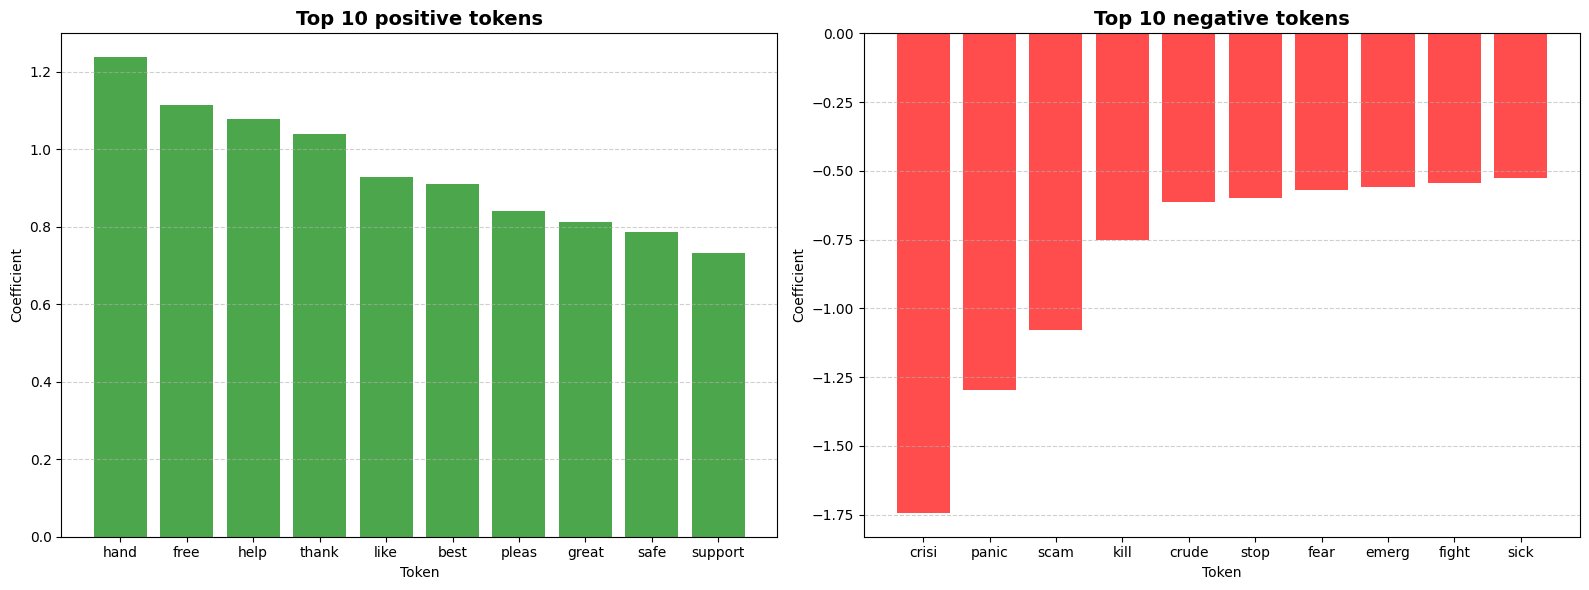

In [46]:
coefs = lr_cv_df.coef_[0]
feature_names = cv_df.get_feature_names_out()

df = pd.DataFrame({
    'token': feature_names,
    'coefficient': coefs
})

top_positive = df.nlargest(10, 'coefficient')
top_negative = df.nsmallest(10, 'coefficient')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(top_positive['token'], top_positive['coefficient'], color='green', alpha=0.7)
axes[0].set_title('Top 10 positive tokens', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Token')
axes[0].set_ylabel('Coefficient')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
axes[0].tick_params(axis='x')

axes[1].bar(top_negative['token'], top_negative['coefficient'], color='red', alpha=0.7)
axes[1].set_title('Top 10 negative tokens', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Token')
axes[1].set_ylabel('Coefficient')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
axes[1].tick_params(axis='x')

plt.tight_layout()
plt.show()


**Ответ:** Разница в коэффициентах для положительных токенов не такая резкая, как разница для отрицательных.

Топ положительных токенов:
1. hand - скорее всего, это были призывы мыть руки чаще -> положительно окрашенные
2. free - что-то выделили бесплатное
3. help - призывы кому-то помогать, тоже положительно окрашенные
4. Далее идут слова с очевидной положительной окраской (балгодарности (thank), слова по типу like/best/great, слова просьбы и поддержки)

Топ отрицательных токенов:
1. crisi - кризис, негативно окрашенное
2. panic, scam - также негативно окрашенные

Для отрицательных токенов crisu так выделился, т.к. кризис являлся самой обсуждаемой проблемой пандемии. Остальные токены являются чуть более общими (но всё ещё отрицательными)

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [52]:
train['UserName'].values

array([35178, 40819, 39249, ..., 41159, 29702,  7104], shape=(23410,))

In [53]:
train['ScreenName'].values

array([80130, 85771, 84201, ..., 86111, 74654, 52056], shape=(23410,))

**Ответ:** Методом пристального взгляда определили, что UserName и ScreenName являются идентификаторами пользователя и экрана (?) - не несут в себе никакой дополнительной информации о твите (работаю практически как id) -> их можно отбросить

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [55]:
train['TweetAt'] = pd.to_datetime(train['TweetAt'], format='%d-%m-%Y')
test['TweetAt'] = pd.to_datetime(test['TweetAt'], format='%d-%m-%Y')
train['TweetAt'].head(5)

25621   2020-04-06
30135   2020-04-10
28899   2020-04-09
5989    2020-03-19
4367    2020-03-18
Name: TweetAt, dtype: datetime64[us]

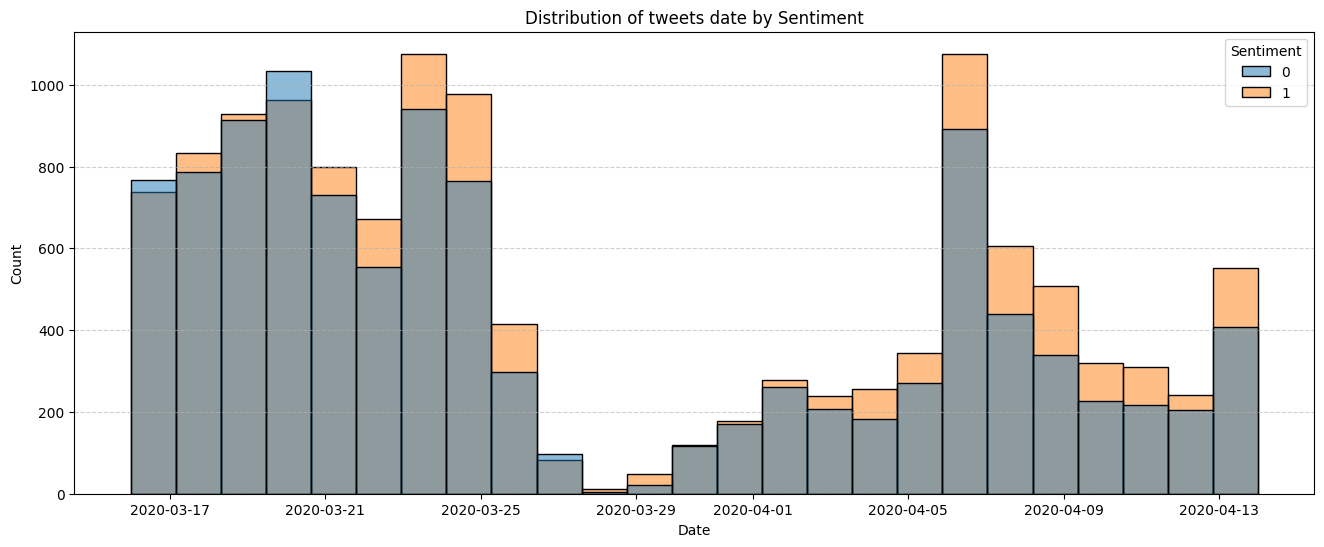

In [ ]:
plt.figure(figsize=(16, 6))

sns.histplot(data=train, x='TweetAt', hue='Sentiment')
plt.title('Distribution of tweets date by Sentiment')
plt.xlabel('Date')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

**Ответ:** В каждом столбце гистограммы количество положительных/отрицательных твитов примерно одинаковое, причём положительных практически всегда больше. В целом, 
TweetAt тоже можно отбросить.


Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [59]:
train['Location'].nunique()

7949

Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

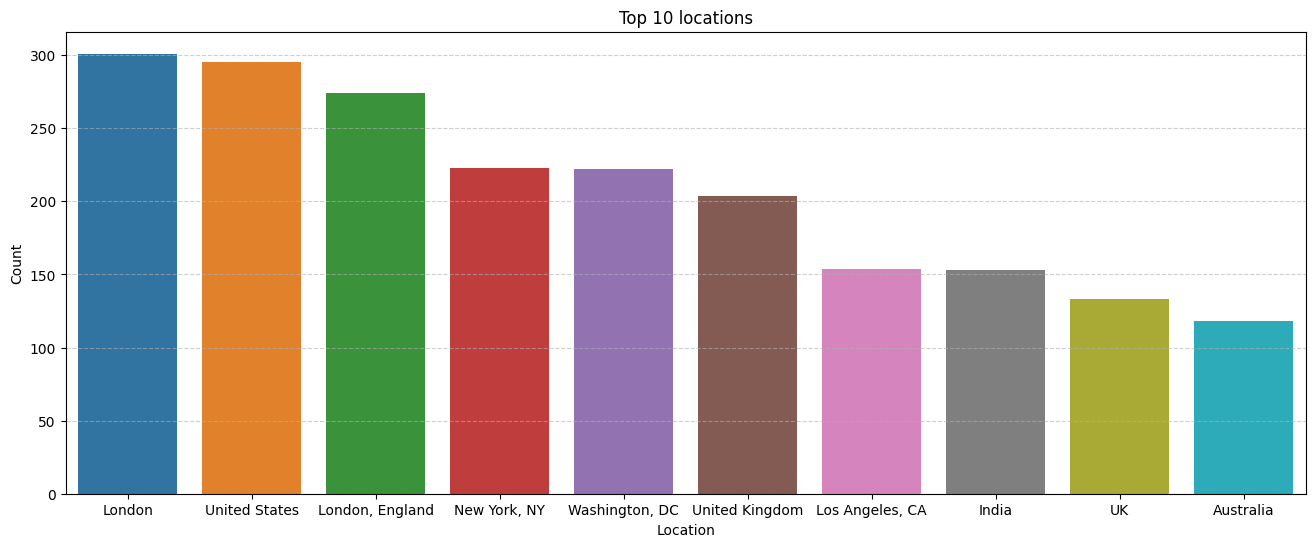

In [61]:
plt.figure(figsize=(16, 6))

loc_count = train['Location'].value_counts()
loc_count = loc_count.drop('Unknown')
top_loc = loc_count.head(10)
sns.barplot(hue=top_loc.index, x=top_loc.index,y=top_loc.values)

plt.title('Top 10 locations')
plt.xlabel('Location')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

In [ ]:
train['WiderLocation'] = train['Location'].apply(lambda x: str(x).split(',')[-1])
test['WiderLocation'] = test['Location'].apply(lambda x: str(x).split(',')[-1])
train['WiderLocation'].nunique() #число уникальных локаций уменьшилось в 1,5 раза

5163

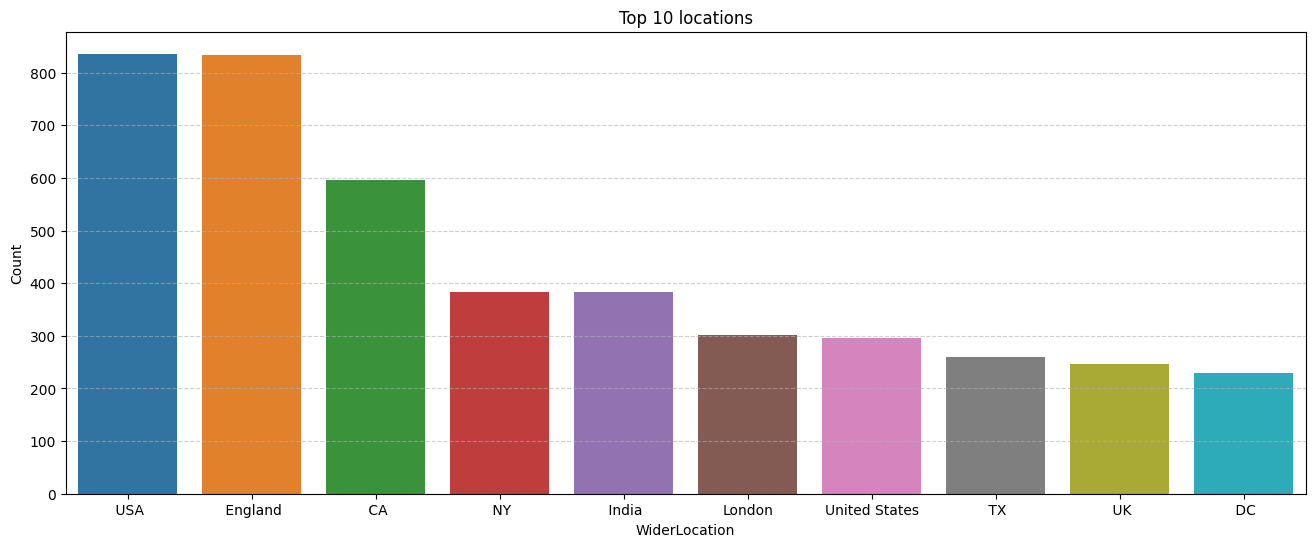

In [ ]:
plt.figure(figsize=(16, 6))

loc_count = train['WiderLocation'].value_counts()
loc_count = loc_count.drop('Unknown')
top_loc = loc_count.head(10)
sns.barplot(hue=top_loc.index, x=top_loc.index,y=top_loc.values)

plt.title('Top 10 locations')
plt.xlabel('WiderLocation')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()
# Самыми популярными стали большие англоязычные страны (USA, England), далее также встречаются города этих стран или сформулированные по-другому названия (NY, London, United State, UK)

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


In [65]:
from sklearn.preprocessing import OneHotEncoder
wider_loс = loc_count[loc_count > 1].index.tolist()
train_filtered = train[train['WiderLocation'].isin(wider_loс)].copy()

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(train_filtered[['WiderLocation']])
feature_names_ohe = ohe.get_feature_names_out(['WiderLocation'])

X_train_ohe = pd.DataFrame(ohe.transform(train_filtered[['WiderLocation']]), columns=feature_names_ohe, index=train_filtered.index)
X_test_ohe = pd.DataFrame(ohe.transform(test[['WiderLocation']]), columns=feature_names_ohe, index=X_test.index)

print(f"Число уникальных локаций, встречающихсяболее 1 раза: {len(ohe.categories_[0])}")

Число уникальных локаций, встречающихсяболее 1 раза: 1158


Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [ ]:
X_train_cv_df_scaled = pd.DataFrame(X_train_cv_df_scaled, index=X_train.index)
ohe_train_rows = X_train_cv_df_scaled.loc[X_train_ohe.index]
X_train_all = pd.concat([ohe_train_rows, X_train_ohe], axis=1)
y_train_all = y_train.loc[X_train_all.index]

X_test_cv_df_scaled = pd.DataFrame(X_test_cv_df_scaled, index=X_test.index)
ohe_test_rows = X_test_cv_df_scaled.loc[X_test_ohe.index]
X_test_all = pd.concat([ohe_test_rows, X_test_ohe], axis=1)
y_test_all = y_test.loc[X_test_all.index]

In [72]:
X_train_all.columns = X_train_all.columns.map(str)
X_test_all.columns = X_test_all.columns.map(str)

lr_finally = LogisticRegression(max_iter=200)
lr_finally.fit(X_train_all, y_train_all)

y_pred_train = lr_finally.predict(X_train_all)
y_pred_test = lr_finally.predict(X_test_all)

print(f'Accuracy на train: {accuracy_score(y_train_all, y_pred_train)}')
print(f'Accuracy на test: {accuracy_score(y_test_all, y_pred_test)}')

Accuracy на train: 0.9917715392061955
Accuracy на test: 0.7921068367550329


**Ответ:** Качество на train выросло, но на test упало (почти на 0.06). Новый признак оказался не очень полезным, т.к.:
1. Он убрал некоторое число твитов с непопулярными локациями и Unknown - не учлись многие токены.
2. Эмоциональная окраска твита в целом не сильно зависит от местоположения
3. Из-за большого числа Unknown-локаций, сам признак составился не очень корректно (возможно, некоторые локации встречались чаще, но у нас нет о них информации)